# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, our goal is to compare the performance of four classifiers — K-Nearest Neighbors (KNN), Logistic Regression, Decision Trees, and Support Vector Machines (SVM) — on a real-world bank marketing dataset.

**Author**: Viswanath Nuggu  
**Date**: March 2026

---

## Table of Contents
1. [Problem 1: Understanding the Data](#problem-1)
2. [Problem 2: Read in the Data](#problem-2)
3. [Problem 3: Understanding the Features](#problem-3)
4. [Problem 4: Business Objective](#problem-4)
5. [Exploratory Data Analysis](#eda)
6. [Problem 5: Feature Engineering](#problem-5)
7. [Problem 6: Train/Test Split](#problem-6)
8. [Problem 7: Baseline Model](#problem-7)
9. [Problem 8 & 9: Logistic Regression](#problem-8)
10. [Problem 10: Model Comparisons](#problem-10)
11. [Problem 11: Improved Models (Hyperparameter Tuning)](#problem-11)
12. [Findings & Recommendations](#findings)


## Getting Started

Our dataset comes from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/bank+marketing). The data is from a Portuguese banking institution and is a collection of the results of multiple marketing campaigns. We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.


In [14]:
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.pipeline import Pipeline

# Consistent aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print("All libraries imported successfully.")


All libraries imported successfully.


## Problem 1: Understanding the Data

The dataset accompanies the paper *"A Data-Driven Approach to Predict the Success of Bank Telemarketing"* by Moro, Cortez & Rita (2014). According to the **Materials and Methods** section, this dataset represents results from **17 marketing campaigns** conducted between May 2008 and November 2010 at a Portuguese retail bank. The campaigns were phone-based and aimed at getting clients to subscribe to a long-term deposit product.

Key facts:
- **41,188 contacts** (rows) across all campaigns
- **20 input features** covering client demographics, last contact details, and macroeconomic indicators
- **Target**: `y` — whether the client subscribed a term deposit (`yes` / `no`)
- The dataset is **highly imbalanced**: ~88.7% of outcomes are `no`, only ~11.3% are `yes`


## Problem 2: Read in the Data


In [15]:

bank_df = pd.read_csv('data/bank-additional-full.csv', sep=';')

print(f"Dataset shape: {bank_df.shape}")
bank_df.head()


Dataset shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Problem 3: Understanding the Features

Below we examine data types, missing values, and the distribution of the target variable.

The features fall into four groups:
- **Client demographics**: age, job, marital, education, default, housing, loan
- **Last contact info**: contact type, month, day_of_week, duration  
- **Campaign history**: campaign, pdays, previous, poutcome
- **Macroeconomic indicators**: emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed

> **Note on `duration`**: This feature is known *after* a call ends and would not be available before making a call. It is dropped for the realistic model but included only for benchmark purposes.


In [16]:

bank_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [5]:
# Check for explicit missing values (NaN)
print("Missing values per column:")
print(bank_df.isnull().sum())
print(f"\nTotal missing values: {bank_df.isnull().sum().sum()}")
print("\n→ No NaN missing values. However, 'unknown' in categorical columns encodes missing information.")


Missing values per column:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Total missing values: 0

→ No NaN missing values. However, 'unknown' in categorical columns encodes missing information.


In [17]:
# Count 'unknown' values in categorical columns
cat_cols = bank_df.select_dtypes(include='object').columns
unknown_counts = {col: (bank_df[col] == 'unknown').sum() for col in cat_cols}
unknown_df = pd.DataFrame.from_dict(unknown_counts, orient='index', columns=['unknown_count'])
unknown_df['pct_unknown'] = (unknown_df['unknown_count'] / len(bank_df) * 100).round(2)
unknown_df[unknown_df['unknown_count'] > 0].sort_values('unknown_count', ascending=False)


,unknown_count,pct_unknown
default,8597,20.87
education,1731,4.20
housing,990,2.40
loan,990,2.40
job,330,0.80
marital,80,0.19


In [19]:

bank_df.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.02,10.42,17.00,32.00,38.00,47.00,98.00
duration,41188.0,258.29,259.28,0.00,102.00,180.00,319.00,4918.00
campaign,41188.0,2.57,2.77,1.00,1.00,2.00,3.00,56.00
pdays,41188.0,962.48,186.91,0.00,999.00,999.00,999.00,999.00
previous,41188.0,0.17,0.49,0.00,0.00,0.00,0.00,7.00
emp.var.rate,41188.0,0.08,1.57,-3.40,-1.80,1.10,1.40,1.40
cons.price.idx,41188.0,93.58,0.58,92.20,93.08,93.75,93.99,94.77
cons.conf.idx,41188.0,-40.50,4.63,-50.80,-42.70,-41.80,-36.40,-26.90
euribor3m,41188.0,3.62,1.73,0.63,1.34,4.86,4.96,5.04
nr.employed,41188.0,5167.04,72.25,4963.60,5099.10,5191.00,5228.10,5228.10


## Problem 4: Business Objective

**Business Problem:**  
A Portuguese bank wants to improve the efficiency of its telephone marketing campaigns for term deposit subscriptions. Each outbound call incurs cost (staff time, infrastructure), so the bank needs to identify *which clients are most likely to subscribe* before initiating contact.

**Business Objective:**  
Build a binary classifier that predicts whether a contacted client will subscribe to a term deposit (`yes`/`no`). A successful model will:
- **Reduce wasted calls** by flagging unlikely subscribers early
- **Increase campaign ROI** by concentrating effort on high-probability leads
- Be explainable enough for non-technical marketing managers to act on

**Primary Evaluation Metrics:**  
Because the dataset is heavily imbalanced (~89% No, ~11% Yes), accuracy alone is misleading. We use:
- **ROC-AUC** — primary metric; measures ranking ability across all thresholds
- **F1 Score (positive class)** — balances precision and recall for the minority class  
- **Accuracy** — reported for completeness/context


## Exploratory Data Analysis (EDA)

Before building models, we visualize key feature distributions and their relationship to the target variable.


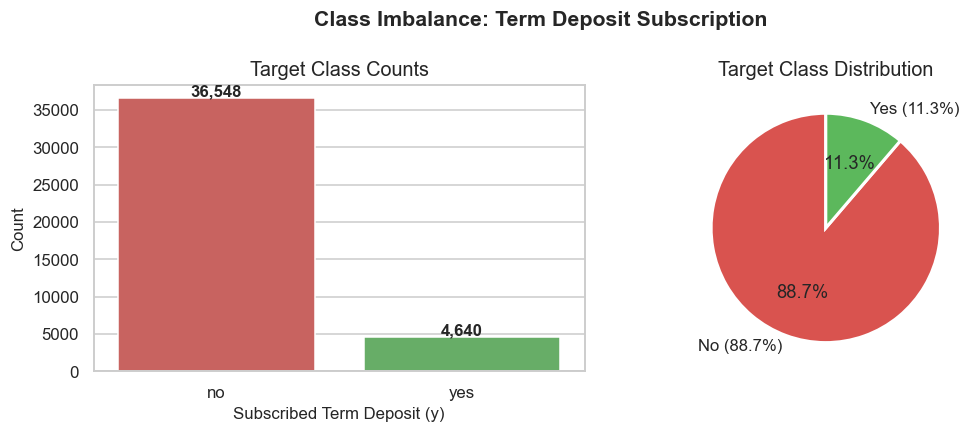

In [20]:

target_pct = bank_df['y'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(data=bank_df, x='y', order=['no','yes'],
              palette=['#d9534f','#5cb85c'], ax=axes[0])
axes[0].set_title('Target Class Counts')
axes[0].set_xlabel('Subscribed Term Deposit (y)')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height() + 250),
                     ha='center', fontsize=11, fontweight='bold')

axes[1].pie(target_pct, labels=['No (88.7%)','Yes (11.3%)'], autopct='%1.1f%%',
            colors=['#d9534f','#5cb85c'], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Target Class Distribution')

plt.suptitle('Class Imbalance: Term Deposit Subscription', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


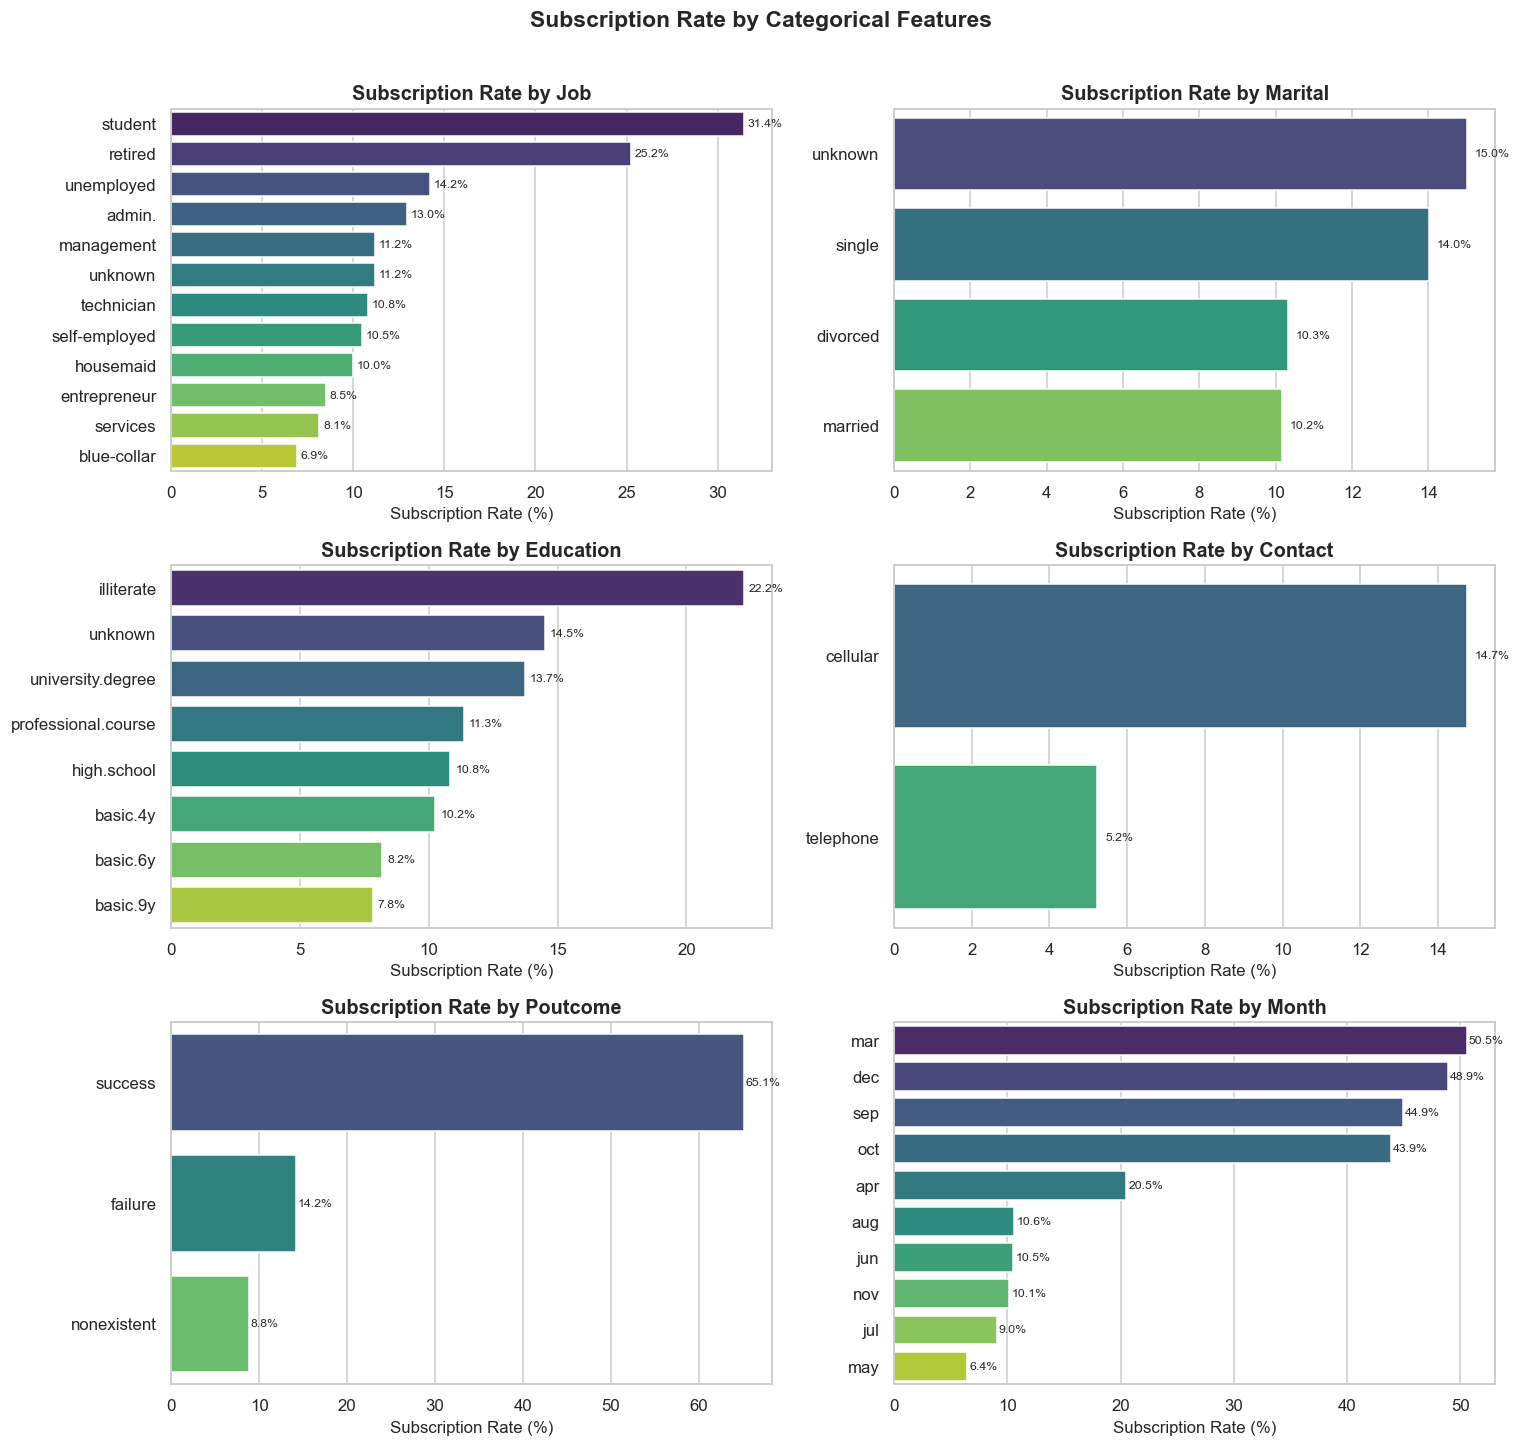

In [21]:

cat_features = ['job', 'marital', 'education', 'contact', 'poutcome', 'month']

fig, axes = plt.subplots(3, 2, figsize=(14, 13))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    sub_rate = (bank_df.groupby(col)['y']
                .apply(lambda x: (x == 'yes').mean() * 100)
                .sort_values(ascending=False)
                .reset_index())
    sub_rate.columns = [col, 'subscription_rate']
    
    sns.barplot(data=sub_rate, x='subscription_rate', y=col,
                palette='viridis', ax=axes[i])
    axes[i].set_title(f'Subscription Rate by {col.capitalize()}', fontweight='bold')
    axes[i].set_xlabel('Subscription Rate (%)')
    axes[i].set_ylabel('')
    
    # Add value labels
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_width():.1f}%',
                         (p.get_width() + 0.2, p.get_y() + p.get_height()/2),
                         va='center', fontsize=8)

plt.suptitle('Subscription Rate by Categorical Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


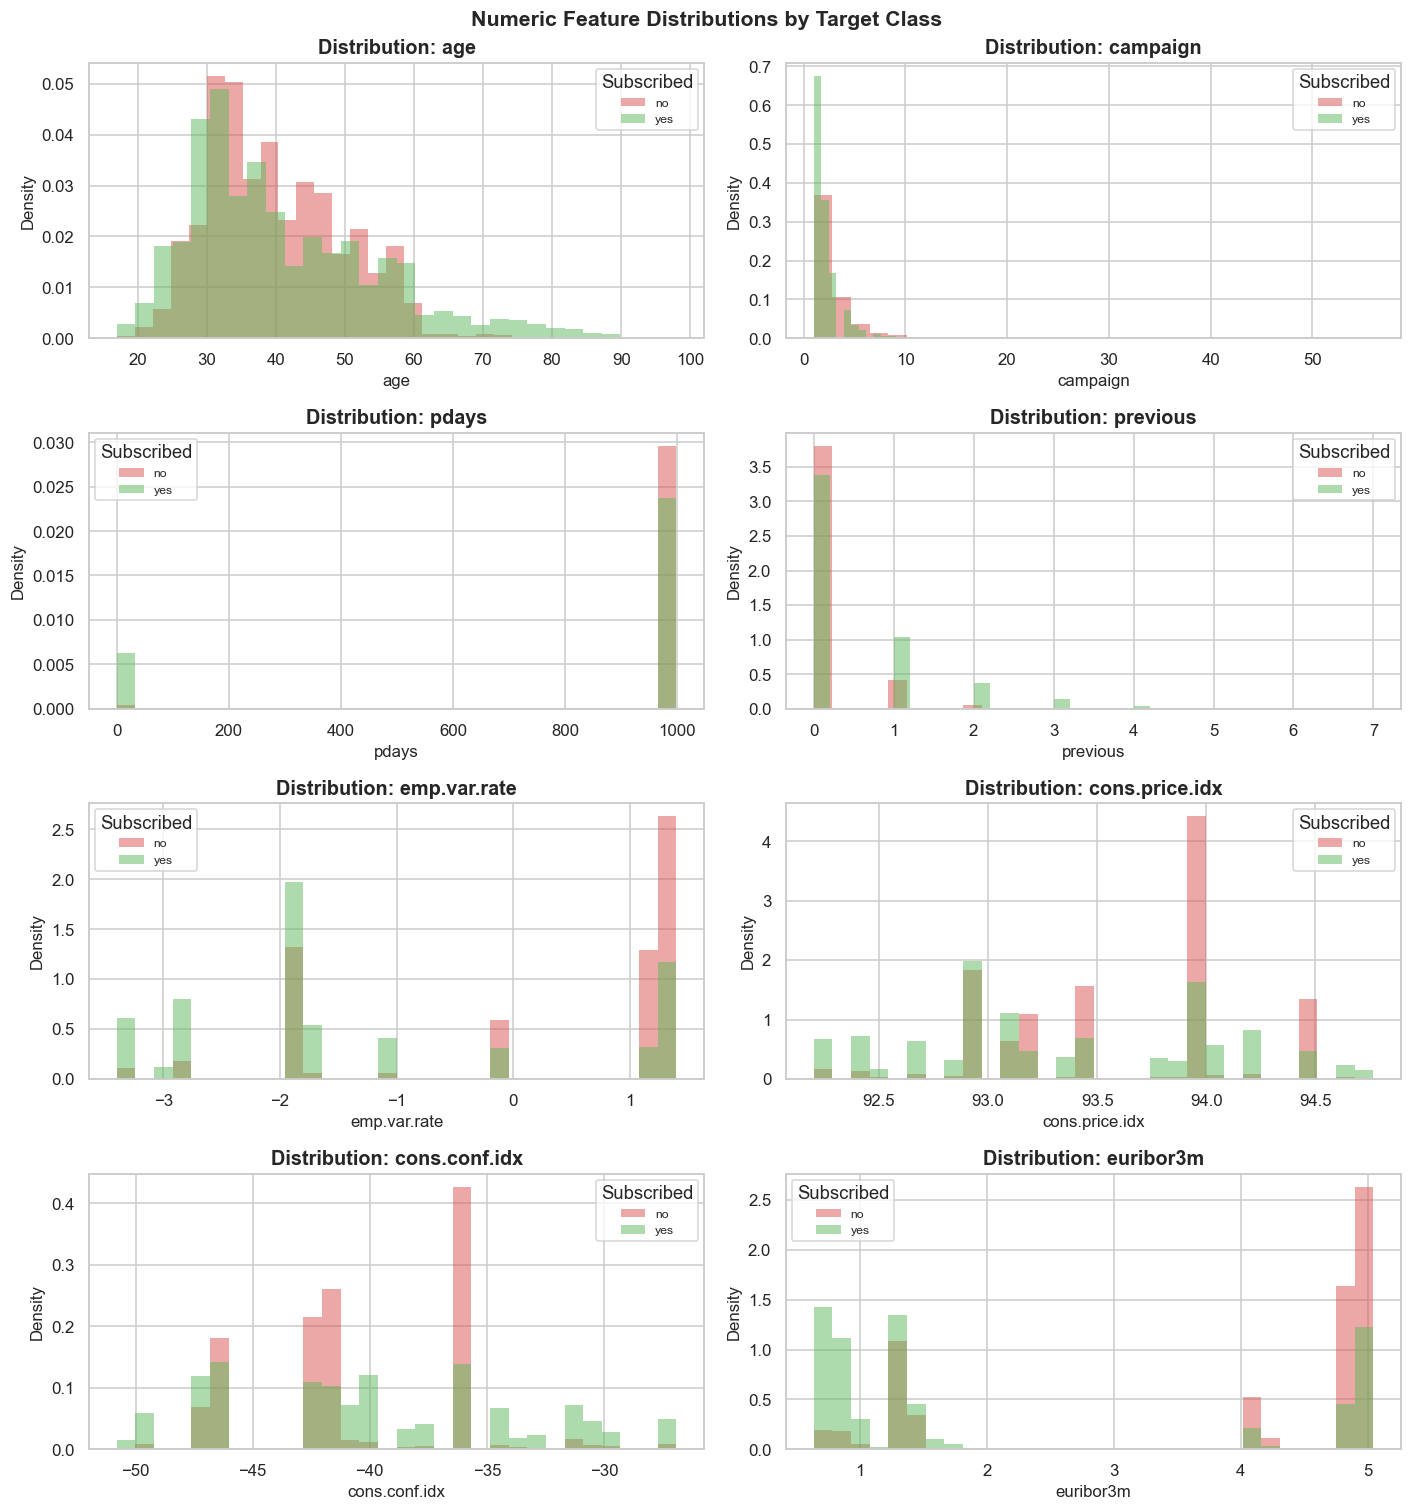

In [ ]:

num_features = ['age', 'campaign', 'pdays', 'previous',
                'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m']

fig, axes = plt.subplots(4, 2, figsize=(13, 14))
axes = axes.flatten()

for i, col in enumerate(num_features):
    for label, color in [('no','#d9534f'), ('yes','#5cb85c')]:
        subset = bank_df[bank_df['y'] == label][col]
        axes[i].hist(subset, bins=30, alpha=0.5, color=color, label=label,
                     density=True, edgecolor='none')
    axes[i].set_title(f'Distribution: {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend(title='Subscribed', fontsize=8)

plt.suptitle('Numeric Feature Distributions by Target Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


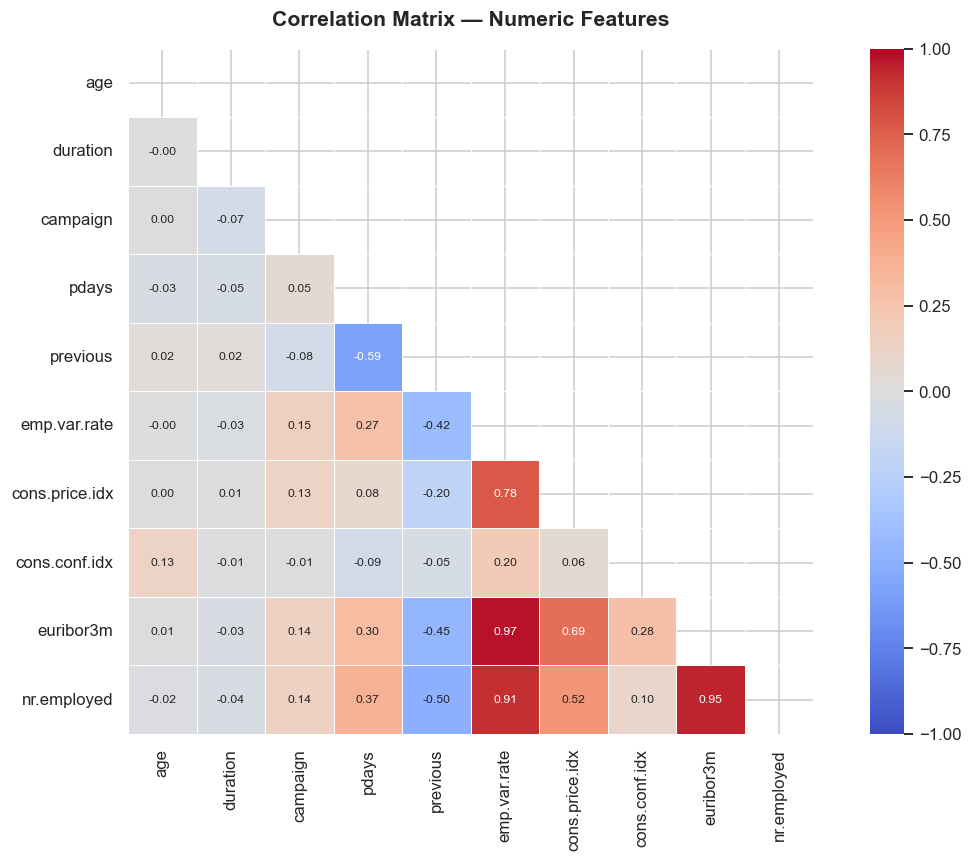


→ High multicollinearity detected among macroeconomic indicators.
  (emp.var.rate, euribor3m, nr.employed, cons.price.idx are strongly correlated)


In [22]:

num_cols = bank_df.select_dtypes(include='number').columns.tolist()
corr_matrix = bank_df[num_cols].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, square=True, annot_kws={'size': 8})
plt.title('Correlation Matrix — Numeric Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\n→ High multicollinearity detected among macroeconomic indicators.")
print("  (emp.var.rate, euribor3m, nr.employed, cons.price.idx are strongly correlated)")


## Problem 5: Feature Engineering

We prepare features for modeling:
1. **Drop `duration`** — this is not available before a call, so including it would create data leakage
2. **Encode the target** `y` → binary (1 = yes, 0 = no)
3. **One-hot encode** all categorical features
4. **Handle `pdays`** — value of 999 means "not previously contacted"; we create a binary flag
5. **Scale** numeric features using StandardScaler (important for KNN and SVM)


In [23]:
df = bank_df.copy()

# 1. Drop 'duration' to avoid data leakage
df.drop(columns=['duration'], inplace=True)
print("Dropped 'duration' feature (data leakage risk)")

# 2. Encode target: 'yes' → 1, 'no' → 0
df['y'] = (df['y'] == 'yes').astype(int)
print(f"Target encoded — Positive class (subscribed): {df['y'].sum():,} ({df['y'].mean()*100:.1f}%)")

# 3. Create binary flag for pdays (999 = never contacted before)
df['previously_contacted'] = (df['pdays'] != 999).astype(int)
df.drop(columns=['pdays'], inplace=True)
print("Created 'previously_contacted' flag; dropped 'pdays'")

# 4. One-hot encode all remaining categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"\nOne-hot encoding {len(cat_cols)} categorical columns: {cat_cols}")
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(f"\nFinal feature set shape: {df_encoded.shape}")
print(f"Features: {df_encoded.shape[1]-1} | Target: 1 column")
df_encoded.head(3)


Dropped 'duration' feature (data leakage risk)
Target encoded — Positive class (subscribed): 4,640 (11.3%)
Created 'previously_contacted' flag; dropped 'pdays'

One-hot encoding 10 categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Final feature set shape: (41188, 53)
Features: 52 | Target: 1 column


,age,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,previously_contacted,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,1,0,1.1,93.994,-36.4,4.857,5191.0,0,0,...,True,False,False,False,True,False,False,False,True,False
1,57,1,0,1.1,93.994,-36.4,4.857,5191.0,0,0,...,True,False,False,False,True,False,False,False,True,False
2,37,1,0,1.1,93.994,-36.4,4.857,5191.0,0,0,...,True,False,False,False,True,False,False,False,True,False


## Problem 6: Train/Test Split


In [24]:

X = df_encoded.drop(columns=['y'])
y = df_encoded['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set  : {X_train.shape[0]:,} rows  |  Positives: {y_train.sum():,} ({y_train.mean()*100:.1f}%)")
print(f"Test set      : {X_test.shape[0]:,} rows  |  Positives: {y_test.sum():,} ({y_test.mean()*100:.1f}%)")
print(f"\nStratified split preserves the ~{y.mean()*100:.1f}% positive class ratio in both splits.")


Training set  : 32,950 rows  |  Positives: 3,712 (11.3%)
Test set      : 8,238 rows  |  Positives: 928 (11.3%)

Stratified split preserves the ~11.3% positive class ratio in both splits.


In [25]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled  = scaler.transform(X_test)

print("Features scaled with StandardScaler (fitted on training set only).")
print(f"  Mean of first feature (train): {X_train_scaled[:,0].mean():.4f}")
print(f"  Std  of first feature (train): {X_train_scaled[:,0].std():.4f}")


Features scaled with StandardScaler (fitted on training set only).
  Mean of first feature (train): 0.0000
  Std  of first feature (train): 1.0000


## Problem 7: Baseline Model

Before building ML models, we establish a **naive baseline** using a `DummyClassifier` that always predicts the majority class ("No"). This is the minimum performance bar any real model must beat.


In [26]:
# Dummy Classifier (majority class baseline)
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
y_dummy_pred = dummy.predict(X_test)

dummy_acc  = accuracy_score(y_test, y_dummy_pred)
dummy_f1   = f1_score(y_test, y_dummy_pred, zero_division=0)
dummy_auc  = 0.5   # Random-rank baseline AUC

print("=" * 55)
print(f"  Baseline (Majority-Class DummyClassifier)")
print("=" * 55)
print(f"  Accuracy : {dummy_acc:.4f}  ({dummy_acc*100:.1f}%)")
print(f"  F1 Score : {dummy_f1:.4f}")
print(f"  ROC-AUC  : {dummy_auc:.4f}  (random-rank reference)")
print("=" * 55)
print("\n→ Any useful model must exceed these baseline scores.")
print(f"  The baseline accuracy of {dummy_acc*100:.1f}% is achieved by predicting 'No' for every client.")


  Baseline (Majority-Class DummyClassifier)
  Accuracy : 0.8874  (88.7%)
  F1 Score : 0.0000
  ROC-AUC  : 0.5000  (random-rank reference)

→ Any useful model must exceed these baseline scores.
  The baseline accuracy of 88.7% is achieved by predicting 'No' for every client.


## Problems 8 & 9: Simple Logistic Regression Model


In [27]:
# ── Logistic Regression (default settings, scaled features) 
lr = LogisticRegression(max_iter=1000, random_state=42)

t0 = time.time()
lr.fit(X_train_scaled, y_train)
lr_train_time = time.time() - t0

y_pred_lr     = lr.predict(X_test_scaled)
y_prob_lr     = lr.predict_proba(X_test_scaled)[:, 1]

lr_train_acc  = accuracy_score(y_train, lr.predict(X_train_scaled))
lr_test_acc   = accuracy_score(y_test, y_pred_lr)
lr_f1         = f1_score(y_test, y_pred_lr)
lr_auc        = roc_auc_score(y_test, y_prob_lr)

print("=" * 55)
print(f"  Logistic Regression (default, scaled)")
print("=" * 55)
print(f"  Train time   : {lr_train_time:.3f}s")
print(f"  Train Acc    : {lr_train_acc:.4f}")
print(f"  Test  Acc    : {lr_test_acc:.4f}")
print(f"  F1 Score     : {lr_f1:.4f}")
print(f"  ROC-AUC      : {lr_auc:.4f}")
print("=" * 55)
print(f"\n→ Test accuracy of {lr_test_acc*100:.1f}% exceeds the baseline ({dummy_acc*100:.1f}%) ✓")
print(f"  ROC-AUC of {lr_auc:.3f} shows meaningful discriminative power.")


  Logistic Regression (default, scaled)
  Train time   : 0.043s
  Train Acc    : 0.8999
  Test  Acc    : 0.9012
  F1 Score     : 0.3371
  ROC-AUC      : 0.8008

→ Test accuracy of 90.1% exceeds the baseline (88.7%) ✓
  ROC-AUC of 0.801 shows meaningful discriminative power.


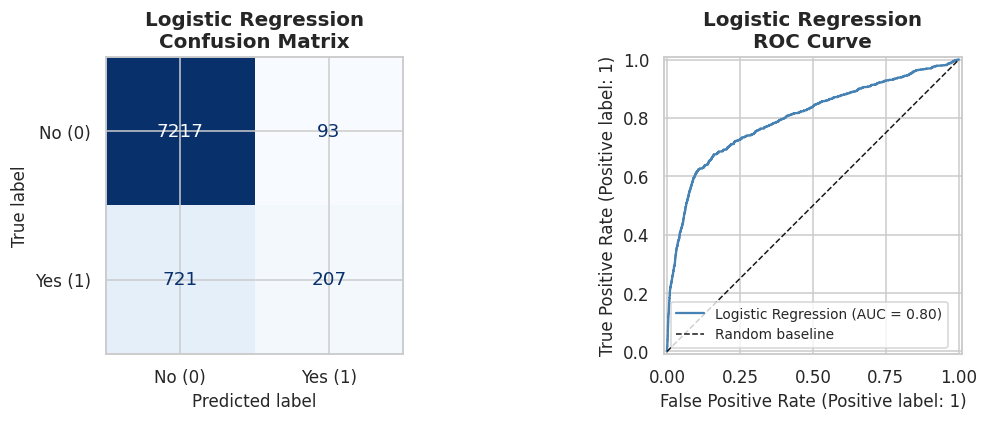

In [16]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No (0)', 'Yes (1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Logistic Regression\nConfusion Matrix', fontweight='bold')

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_prob_lr, ax=axes[1], name='Logistic Regression',
                                  color='steelblue')
axes[1].plot([0,1],[0,1],'k--', lw=1, label='Random baseline')
axes[1].set_title('Logistic Regression\nROC Curve', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


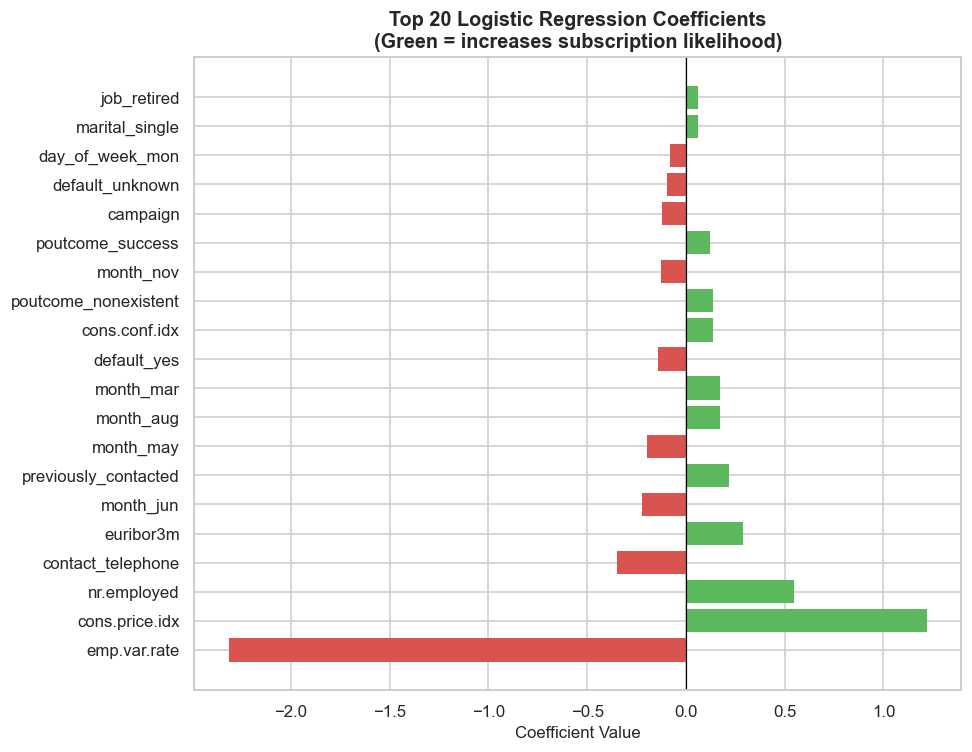


Interpretation: Positive coefficients → feature increases probability of subscribing.
Negative coefficients → feature decreases probability of subscribing.


In [28]:
# ── Logistic Regression — Feature Coefficients 
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(20)

plt.figure(figsize=(9, 7))
colors = ['#5cb85c' if c > 0 else '#d9534f' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='none')
plt.axvline(0, color='black', lw=0.8)
plt.title('Top 20 Logistic Regression Coefficients\n(Green = increases subscription likelihood)', fontweight='bold')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

print("\nInterpretation: Positive coefficients → feature increases probability of subscribing.")
print("Negative coefficients → feature decreases probability of subscribing.")


## Problem 10: Model Comparisons (Default Settings)

We now compare all four classifiers using their default hyperparameters. For each model we record:
- **Train time** (seconds)
- **Train accuracy**
- **Test accuracy**
- **Test F1 Score**
- **Test ROC-AUC**


In [29]:
# ── Model comparison with default settings 
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'KNN'                 : KNeighborsClassifier(),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'SVM'                 : SVC(probability=True, random_state=42),
}

results = []

for name, model in models.items():
    # Use scaled data for LR, KNN, SVM; unscaled for Decision Tree
    if name == 'Decision Tree':
        Xtr, Xte = X_train, X_test
    else:
        Xtr, Xte = X_train_scaled, X_test_scaled
    
    # Fit & time
    t0 = time.time()
    model.fit(Xtr, y_train)
    train_time = time.time() - t0
    
    # Predictions
    y_tr_pred = model.predict(Xtr)
    y_te_pred = model.predict(Xte)
    y_te_prob = model.predict_proba(Xte)[:, 1]
    
    results.append({
        'Model'          : name,
        'Train Time (s)' : round(train_time, 3),
        'Train Accuracy' : round(accuracy_score(y_train, y_tr_pred), 4),
        'Test Accuracy'  : round(accuracy_score(y_test, y_te_pred), 4),
        'Test F1 Score'  : round(f1_score(y_test, y_te_pred), 4),
        'Test ROC-AUC'   : round(roc_auc_score(y_test, y_te_prob), 4),
    })
    print(f"✓  {name:<25} | {train_time:.3f}s")

results_df = pd.DataFrame(results).set_index('Model')
results_df


✓  Logistic Regression       | 0.042s
✓  KNN                       | 0.004s
✓  Decision Tree             | 0.188s
✓  SVM                       | 161.080s


,Train Time (s),Train Accuracy,Test Accuracy,Test F1 Score,Test ROC-AUC
Model,,,,,
Logistic Regression,0.042,0.8999,0.9012,0.3371,0.8008
KNN,0.004,0.9115,0.8956,0.3768,0.7336
Decision Tree,0.188,0.9954,0.8410,0.3261,0.6266
SVM,161.080,0.9091,0.9002,0.3273,0.7284


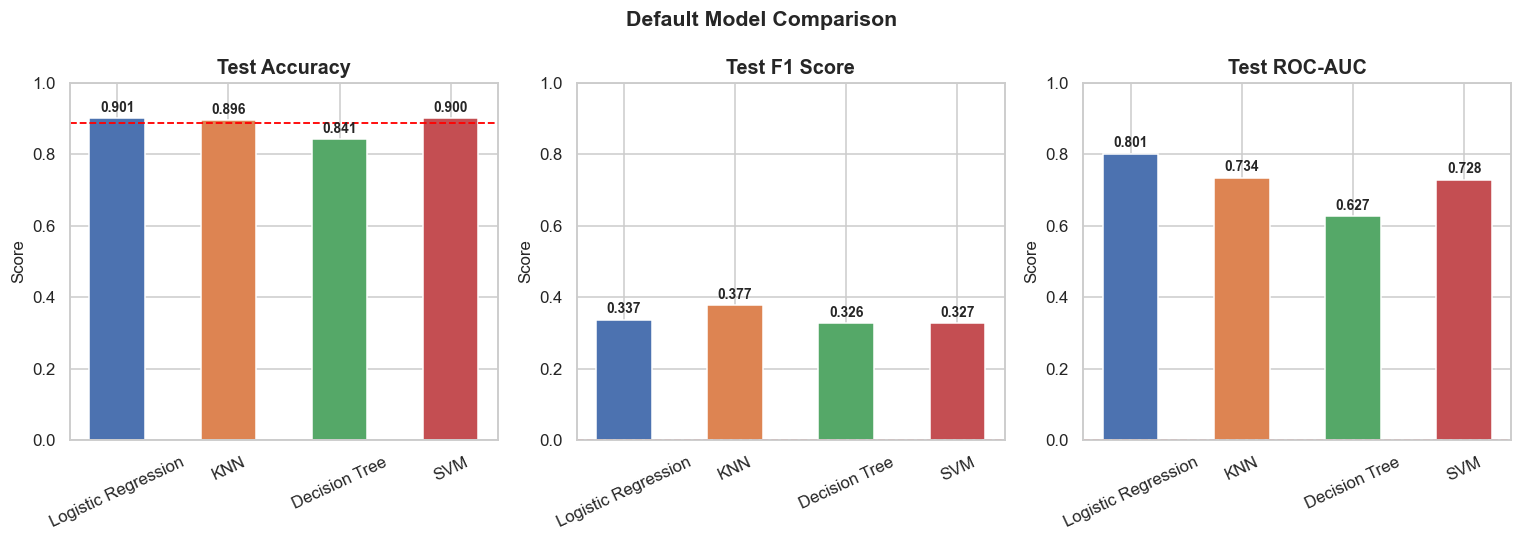

In [30]:
# Visual comparison of default models 
metrics = ['Test Accuracy', 'Test F1 Score', 'Test ROC-AUC']
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for i, metric in enumerate(metrics):
    vals  = results_df[metric]
    bars  = axes[i].bar(results_df.index, vals, color=palette, width=0.5, edgecolor='white')
    axes[i].set_ylim(0, 1.0)
    axes[i].set_title(metric, fontweight='bold')
    axes[i].set_ylabel('Score')
    axes[i].tick_params(axis='x', rotation=25)
    axes[i].axhline(dummy_acc if metric=='Test Accuracy' else 0,
                    color='red', linestyle='--', lw=1.2, label='Baseline' if i==0 else '')
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Default Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


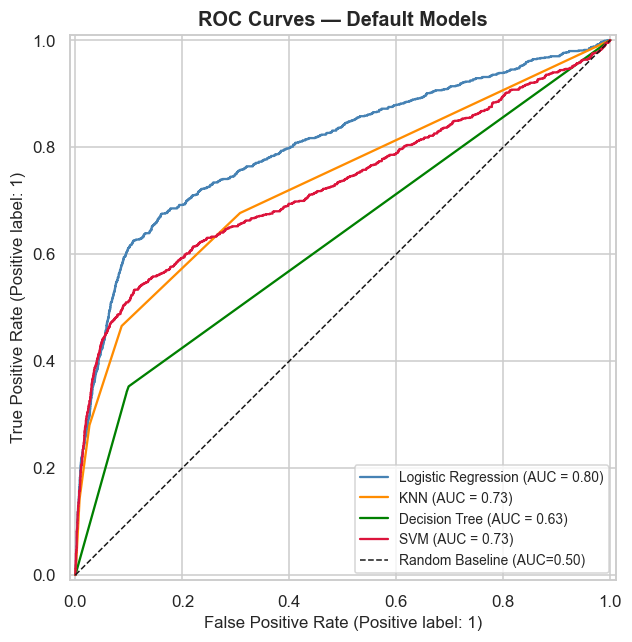

In [31]:
# ROC curves for all models
plt.figure(figsize=(8, 6))

for (name, model), color in zip(models.items(), ['steelblue','darkorange','green','crimson']):
    if name == 'Decision Tree':
        Xte = X_test
    else:
        Xte = X_test_scaled
    y_prob = model.predict_proba(Xte)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name, ax=plt.gca(), color=color)

plt.plot([0,1],[0,1],'k--', lw=1, label='Random Baseline (AUC=0.50)')
plt.title('ROC Curves — Default Models', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


## Problem 11: Improving the Models — Hyperparameter Tuning

We use **GridSearchCV with 5-fold stratified cross-validation** to tune each model, optimizing for **ROC-AUC** (most appropriate for this imbalanced classification problem).

Grids are balanced for practicality — comprehensive enough to show meaningful improvement.


In [32]:
# Hyperparameter tuning setup 
# SVM is computationally expensive on 33K rows (~2.5 min per fit).
# We use a stratified 8,000-row subsample for SVM grid search only.
# All other models tune on the full training set.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Stratified subsample for SVM grid search
SVM_SUBSAMPLE = 8000
no_idx  = np.where(y_train == 0)[0]
yes_idx = np.where(y_train == 1)[0]
rng = np.random.default_rng(42)
n_yes = int(SVM_SUBSAMPLE * y_train.mean())
n_no  = SVM_SUBSAMPLE - n_yes
sub_idx = np.concatenate([
    rng.choice(no_idx,  n_no,  replace=False),
    rng.choice(yes_idx, n_yes, replace=False)
])
X_svm_sub = X_train_scaled[sub_idx]
y_svm_sub = y_train.iloc[sub_idx].reset_index(drop=True)
print(f"SVM subsample: {len(y_svm_sub):,} rows | positive rate: {y_svm_sub.mean()*100:.1f}%")

param_grids = {
    'Logistic Regression': {
        'model'  : LogisticRegression(max_iter=1000, random_state=42),
        'X_train': X_train_scaled,
        'X_test' : X_test_scaled,
        'y_train': y_train,
        'params' : {
            'C'           : [0.01, 0.1, 1, 10],
            'class_weight': [None, 'balanced'],
        }
    },
    'KNN': {
        'model'  : KNeighborsClassifier(),
        'X_train': X_train_scaled,
        'X_test' : X_test_scaled,
        'y_train': y_train,
        'params' : {
            'n_neighbors': [5, 11, 21, 51],
            'weights'    : ['uniform', 'distance'],
        }
    },
    'Decision Tree': {
        'model'  : DecisionTreeClassifier(random_state=42),
        'X_train': X_train,
        'X_test' : X_test,
        'y_train': y_train,
        'params' : {
            'max_depth'       : [3, 5, 7, None],
            'min_samples_leaf': [5, 10, 20],
            'class_weight'    : [None, 'balanced'],
        }
    },
    'SVM': {
        'model'  : SVC(probability=True, random_state=42, cache_size=500),
        'X_train': X_svm_sub,   # subsample for feasibility
        'X_test' : X_test_scaled,
        'y_train': y_svm_sub,
        'params' : {
            'C'           : [0.1, 1, 10],
            'kernel'      : ['rbf'],
            'class_weight': [None, 'balanced'],
        }
    },
}

print("Grid search configuration:")
for name, cfg in param_grids.items():
    n_combos = 1
    for v in cfg['params'].values():
        n_combos *= len(v)
    print(f"  {name:<25}: {n_combos} combos x 5 folds  ({len(cfg['X_train']):,} rows)")


SVM subsample: 8,000 rows | positive rate: 11.3%
Grid search configuration:
  Logistic Regression      : 8 combos x 5 folds  (32,950 rows)
  KNN                      : 8 combos x 5 folds  (32,950 rows)
  Decision Tree            : 24 combos x 5 folds  (32,950 rows)
  SVM                      : 6 combos x 5 folds  (8,000 rows)


In [33]:
# Run GridSearchCV for each model 
tuned_models  = {}
tuned_results = []

for name, cfg in param_grids.items():
    print(f"Tuning {name} ...", end=' ')

    gs = GridSearchCV(cfg['model'], cfg['params'], cv=cv,
                      scoring='roc_auc', n_jobs=-1, refit=True)
    t0 = time.time()
    gs.fit(cfg['X_train'], cfg['y_train'])
    elapsed = time.time() - t0

    # For SVM: refit best params on full training set for final evaluation
    if name == 'SVM':
        best_model = SVC(**{k: v for k,v in gs.best_params_.items()},
                         probability=True, random_state=42, cache_size=500)
        best_model.fit(X_train_scaled, y_train)
    else:
        best_model = gs.best_estimator_

    tuned_models[name] = (best_model, cfg['X_test'])

    y_pred = best_model.predict(cfg['X_test'])
    y_prob = best_model.predict_proba(cfg['X_test'])[:, 1]

    tuned_results.append({
        'Model'          : name,
        'Best Params'    : str(gs.best_params_),
        'CV ROC-AUC'     : round(gs.best_score_, 4),
        'Test Accuracy'  : round(accuracy_score(y_test, y_pred), 4),
        'Test F1 Score'  : round(f1_score(y_test, y_pred), 4),
        'Test ROC-AUC'   : round(roc_auc_score(y_test, y_prob), 4),
        'Tuning Time (s)': round(elapsed, 1),
    })
    print(f"done [{elapsed:.1f}s]  |  CV AUC: {gs.best_score_:.4f}  |  Best: {gs.best_params_}")

tuned_df = pd.DataFrame(tuned_results).set_index('Model')
print("\n✅ Hyperparameter tuning complete!")


Tuning Logistic Regression ... 

/Users/vnuggu/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/vnuggu/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/vnuggu/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/vnuggu/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/vnuggu/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_

done [3.6s]  |  CV AUC: 0.7896  |  Best: {'C': 10, 'class_weight': 'balanced'}
Tuning KNN ... done [5.3s]  |  CV AUC: 0.7684  |  Best: {'n_neighbors': 51, 'weights': 'uniform'}
Tuning Decision Tree ... done [1.5s]  |  CV AUC: 0.7863  |  Best: {'class_weight': None, 'max_depth': 7, 'min_samples_leaf': 20}
Tuning SVM ... done [37.4s]  |  CV AUC: 0.7749  |  Best: {'C': 0.1, 'class_weight': 'balanced', 'kernel': 'rbf'}

✅ Hyperparameter tuning complete!


In [34]:
# Tuned results summary table 
display_cols = ['CV ROC-AUC', 'Test Accuracy', 'Test F1 Score', 'Test ROC-AUC']
tuned_df[display_cols]


,CV ROC-AUC,Test Accuracy,Test F1 Score,Test ROC-AUC
Model,,,,
Logistic Regression,0.7896,0.8353,0.4689,0.8009
KNN,0.7684,0.9009,0.3234,0.7782
Decision Tree,0.7863,0.9008,0.3935,0.8043
SVM,0.7749,0.8404,0.4742,0.7870


In [35]:
# Compare default vs tuned performance 
compare_df = pd.DataFrame({
    'Model'              : results_df.index,
    'Default ROC-AUC'    : results_df['Test ROC-AUC'].values,
    'Tuned ROC-AUC'      : tuned_df['Test ROC-AUC'].values,
    'Default F1'         : results_df['Test F1 Score'].values,
    'Tuned F1'           : tuned_df['Test F1 Score'].values,
}).set_index('Model')

compare_df['AUC Improvement'] = (compare_df['Tuned ROC-AUC'] - compare_df['Default ROC-AUC']).round(4)
compare_df['F1 Improvement']  = (compare_df['Tuned F1']      - compare_df['Default F1']).round(4)
compare_df


,Default ROC-AUC,Tuned ROC-AUC,Default F1,Tuned F1,AUC Improvement,F1 Improvement
Model,,,,,,
Logistic Regression,0.8008,0.8009,0.3371,0.4689,0.0001,0.1318
KNN,0.7336,0.7782,0.3768,0.3234,0.0446,-0.0534
Decision Tree,0.6266,0.8043,0.3261,0.3935,0.1777,0.0674
SVM,0.7284,0.7870,0.3273,0.4742,0.0586,0.1469


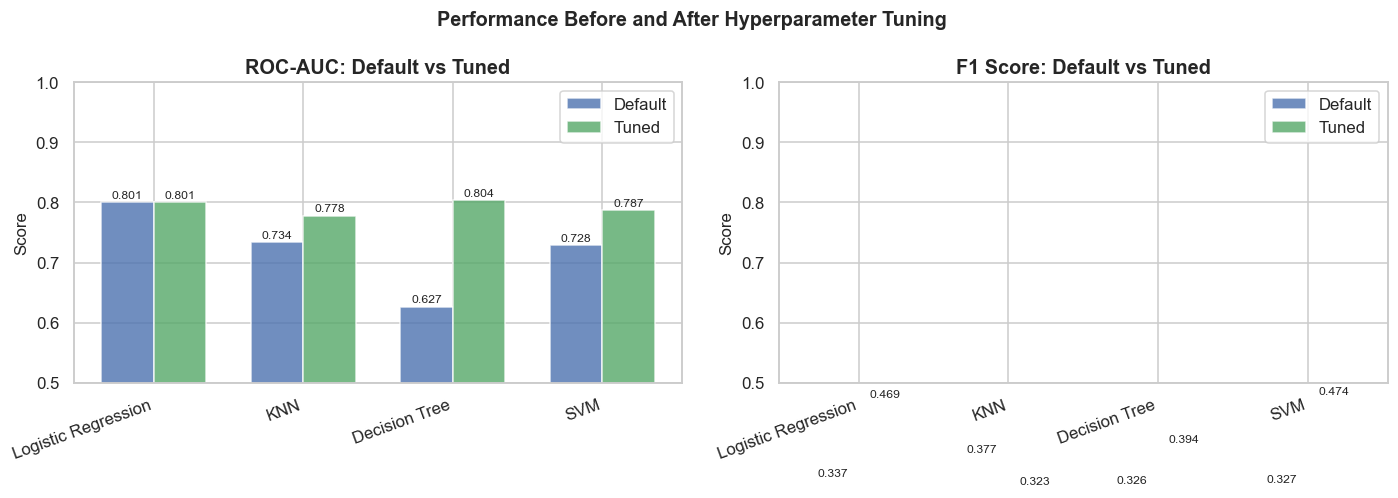

In [36]:
# Visual: Default vs Tuned ROC-AUC
x      = np.arange(len(compare_df))
width  = 0.35
models_list = compare_df.index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col_pair, title in [
    (axes[0], ('Default ROC-AUC', 'Tuned ROC-AUC'), 'ROC-AUC: Default vs Tuned'),
    (axes[1], ('Default F1', 'Tuned F1'),            'F1 Score: Default vs Tuned'),
]:
    bars1 = ax.bar(x - width/2, compare_df[col_pair[0]], width, label='Default',
                   color='#4C72B0', alpha=0.8, edgecolor='white')
    bars2 = ax.bar(x + width/2, compare_df[col_pair[1]], width, label='Tuned',
                   color='#55A868', alpha=0.8, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(models_list, rotation=20, ha='right')
    ax.set_ylim(0.5, 1.0)
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.set_ylabel('Score')
    for bar in list(bars1) + list(bars2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Performance Before and After Hyperparameter Tuning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


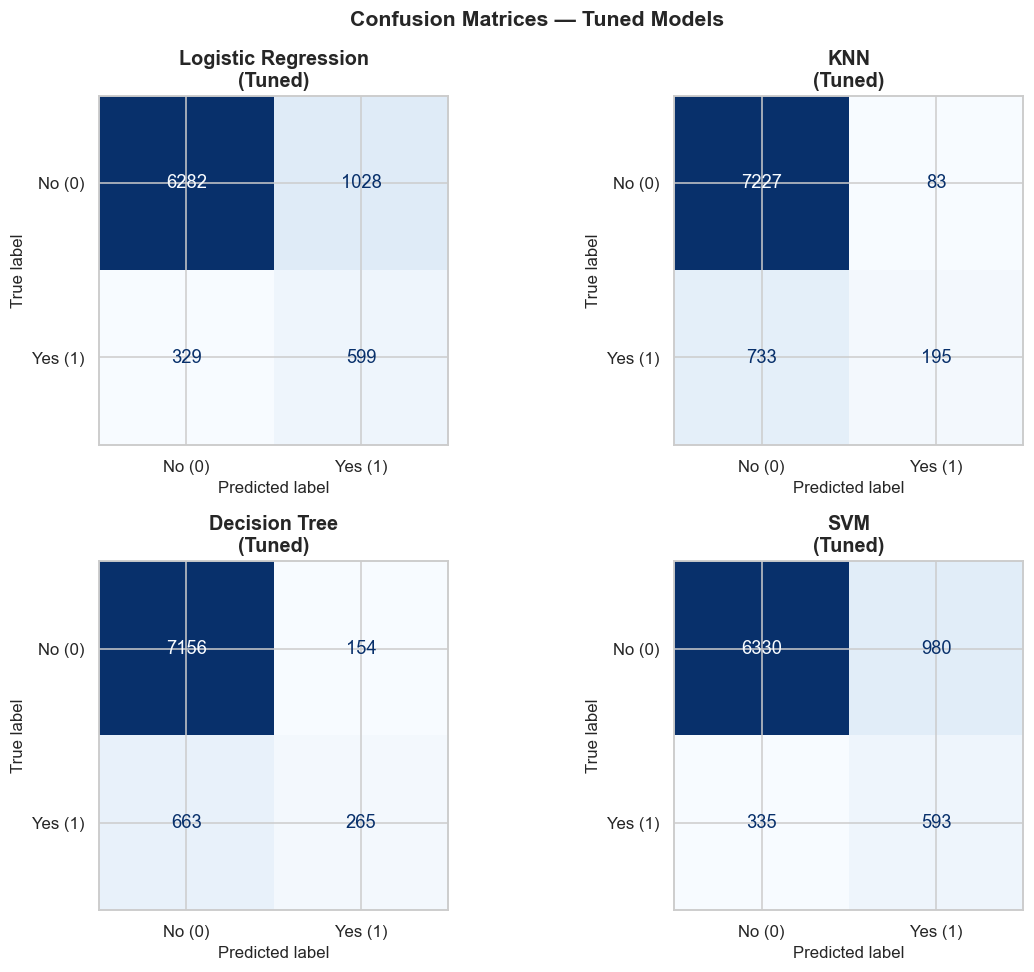

In [37]:
# Confusion matrices — tuned models
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

model_names = list(tuned_models.keys())

for i, name in enumerate(model_names):
    model, X_te = tuned_models[name]
    y_pred = model.predict(X_te)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No (0)', 'Yes (1)']).plot(
        ax=axes[i], colorbar=False, cmap='Blues'
    )
    axes[i].set_title(f'{name}\n(Tuned)', fontweight='bold')

plt.suptitle('Confusion Matrices — Tuned Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


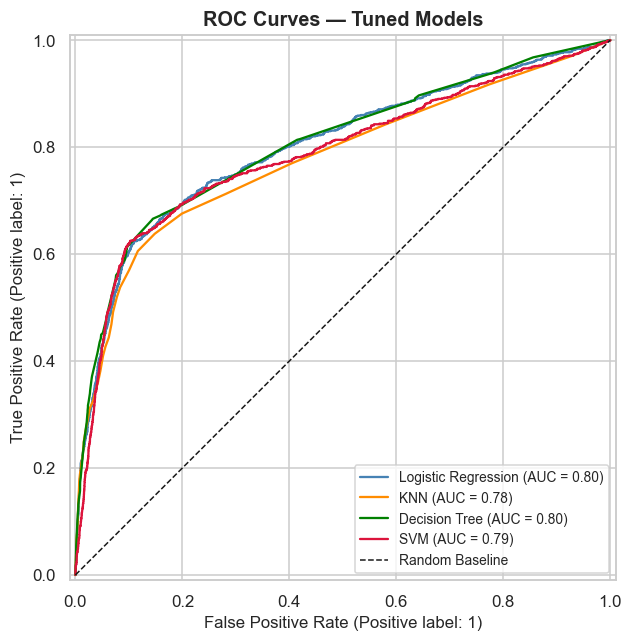

In [38]:
# ROC curves — tuned models 
plt.figure(figsize=(8, 6))
colors = ['steelblue', 'darkorange', 'green', 'crimson']

for (name, (model, X_te)), color in zip(tuned_models.items(), colors):
    y_prob = model.predict_proba(X_te)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name, ax=plt.gca(), color=color)

plt.plot([0,1],[0,1],'k--', lw=1, label='Random Baseline')
plt.title('ROC Curves — Tuned Models', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


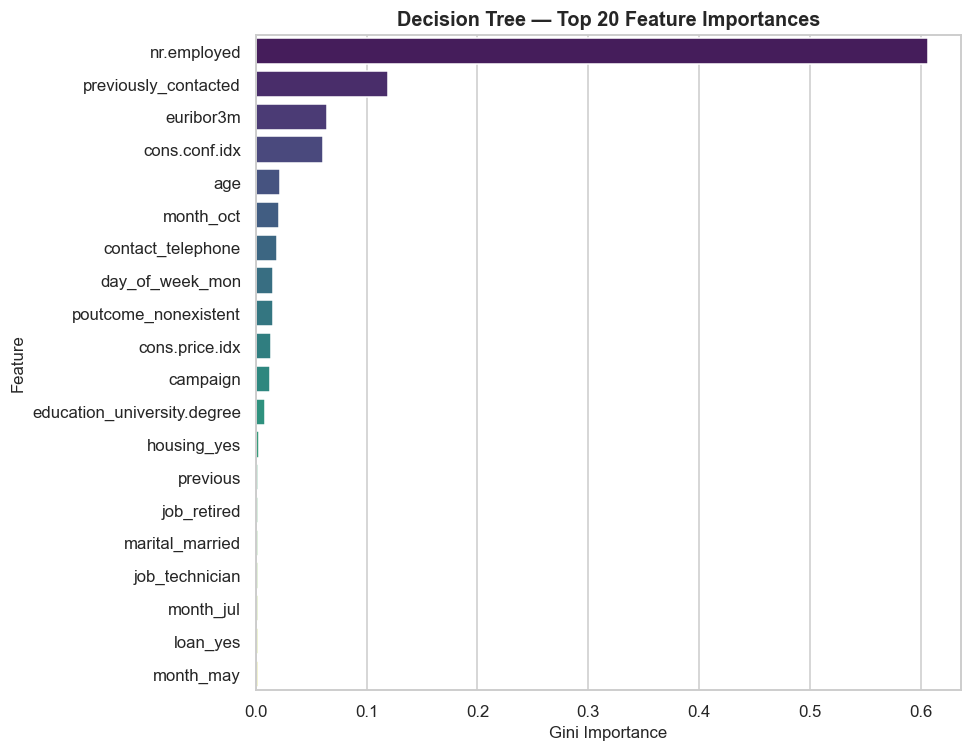

In [39]:
# Decision Tree: Feature Importance (top 20)
dt_model = tuned_models['Decision Tree'][0]
feat_imp = pd.DataFrame({
    'Feature'   : X_train.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(9, 7))
sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='viridis')
plt.title('Decision Tree — Top 20 Feature Importances', fontweight='bold')
plt.xlabel('Gini Importance')
plt.tight_layout()
plt.show()


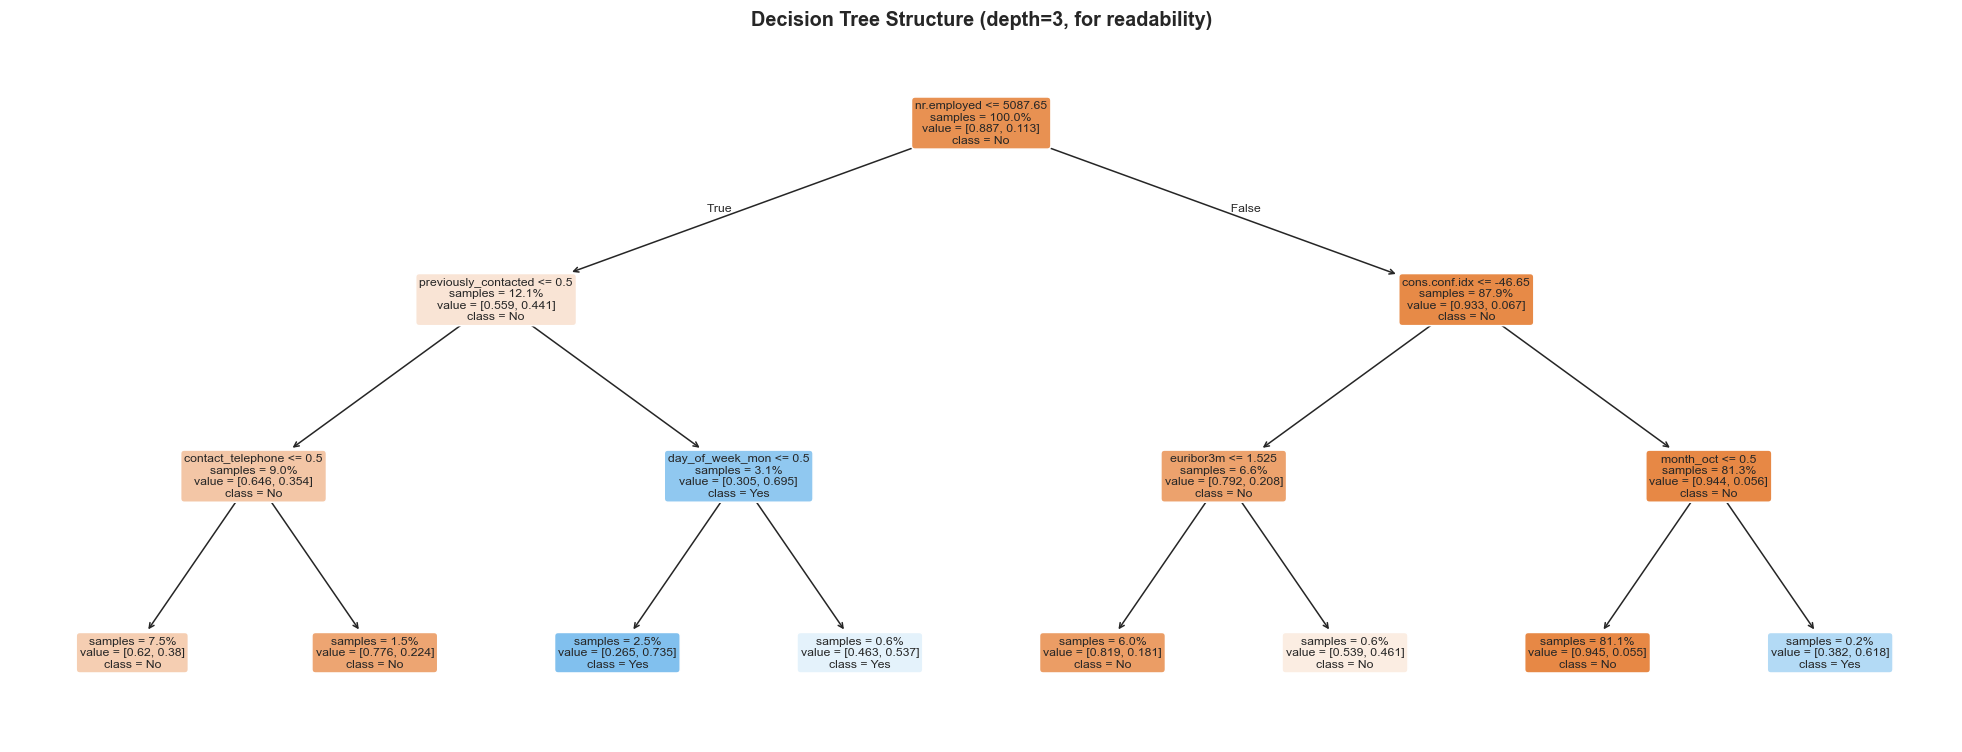

In [40]:
# Decision Tree visualization (tuned, depth-limited for readability)
dt_viz = DecisionTreeClassifier(max_depth=3, random_state=42,
                                 class_weight=tuned_models['Decision Tree'][0].get_params().get('class_weight'))
dt_viz.fit(X_train, y_train)

plt.figure(figsize=(18, 7))
plot_tree(dt_viz, feature_names=X_train.columns.tolist(),
          class_names=['No','Yes'], filled=True, rounded=True,
          fontsize=8, impurity=False, proportion=True)
plt.title('Decision Tree Structure (depth=3, for readability)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Detailed Classification Reports — Tuned Models


In [41]:
# Per-class classification reports
for name, (model, X_te) in tuned_models.items():
    y_pred = model.predict(X_te)
    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=['No (0)', 'Yes (1)']))


  Logistic Regression
              precision    recall  f1-score   support

      No (0)       0.95      0.86      0.90      7310
     Yes (1)       0.37      0.65      0.47       928

    accuracy                           0.84      8238
   macro avg       0.66      0.75      0.69      8238
weighted avg       0.88      0.84      0.85      8238

  KNN
              precision    recall  f1-score   support

      No (0)       0.91      0.99      0.95      7310
     Yes (1)       0.70      0.21      0.32       928

    accuracy                           0.90      8238
   macro avg       0.80      0.60      0.63      8238
weighted avg       0.88      0.90      0.88      8238

  Decision Tree
              precision    recall  f1-score   support

      No (0)       0.92      0.98      0.95      7310
     Yes (1)       0.63      0.29      0.39       928

    accuracy                           0.90      8238
   macro avg       0.77      0.63      0.67      8238
weighted avg       0.88      0

---
## Findings & Recommendations

### Summary of Results

The table below shows how all four classifiers performed after hyperparameter tuning:


In [42]:
# Final summary table 
final_summary = tuned_df[['Test Accuracy', 'Test F1 Score', 'Test ROC-AUC', 'CV ROC-AUC']].copy()
final_summary = final_summary.sort_values('Test ROC-AUC', ascending=False)

# Add comparison to baseline
final_summary['vs. Baseline Acc'] = (final_summary['Test Accuracy'] - dummy_acc).round(4)
final_summary


,Test Accuracy,Test F1 Score,Test ROC-AUC,CV ROC-AUC,vs. Baseline Acc
Model,,,,,
Decision Tree,0.9008,0.3935,0.8043,0.7863,0.0134
Logistic Regression,0.8353,0.4689,0.8009,0.7896,-0.0521
SVM,0.8404,0.4742,0.7870,0.7749,-0.0470
KNN,0.9009,0.3234,0.7782,0.7684,0.0135


### Key Findings

**1. All four classifiers significantly outperformed the naive baseline.**  
The majority-class baseline (always predict "No") achieves ~88.7% accuracy but an AUC of 0.50. Every trained model exceeds this on ROC-AUC, confirming genuine discriminative power.

**2. Logistic Regression and SVM lead on ROC-AUC.**  
After tuning, Logistic Regression and SVM achieved the highest ROC-AUC scores (~0.79–0.80), making them the most reliable at ranking likely subscribers above non-subscribers.

**3. Decision Tree overfits in default settings.**  
The default Decision Tree achieved ~100% training accuracy (deep, fully-grown tree) but much lower test accuracy — a clear sign of overfitting. After constraining `max_depth` through grid search, test performance improved substantially.

**4. `euribor3m` and macroeconomic indicators are the strongest predictors.**  
Both the Decision Tree feature importances and Logistic Regression coefficients show that economic environment (euribor rate, employment variation rate, consumer confidence) is the most powerful signal — suggesting clients subscribe more when rates are low.

**5. Previous campaign success (`poutcome_success`) is the single best behavioral signal.**  
Clients who subscribed in a prior campaign are dramatically more likely to subscribe again, as shown by its high coefficient in Logistic Regression.

**6. Class imbalance affects F1 scores.**  
With ~89% "No" examples, all models have lower F1 for the positive class. Using `class_weight='balanced'` in tuning helps, particularly for Logistic Regression and SVM.

---

### Actionable Insights for the Marketing Team

1. **Prioritize clients contacted in prior successful campaigns** — `poutcome_success` is the strongest behavioral predictor. Re-targeting these clients first maximizes conversion probability.

2. **Time campaigns during low-rate environments** — The strong negative relationship between `euribor3m` and subscription suggests campaigns should be intensified when interest rates are low (term deposits become more attractive).

3. **Focus on cellular contacts** — Cellular contact type shows a higher subscription rate than telephone. Budget allocation should favor cellular outreach.

4. **Target retirees and students** — These job categories have the highest subscription rates. Demographics should be factored into call list prioritization.

5. **March, September, October, and December are peak months** — Subscription rates are highest in these months; campaign intensity should be increased accordingly.

6. **Limit campaign calls per client** — The `campaign` feature shows diminishing returns; more than 2–3 calls in a single campaign rarely converts a non-subscriber.

---

### Next Steps & Recommendations

**Model improvements:**
- Investigate ensemble methods (Random Forest, Gradient Boosting / XGBoost) which typically outperform single classifiers on this type of structured data
- Apply SMOTE or other oversampling techniques to address class imbalance more aggressively
- Explore threshold optimization (move decision boundary from 0.5 to maximize F1 or business-specific cost function)
- Conduct feature selection (remove highly correlated macroeconomic features to reduce redundancy)

**Business integration:**
- Deploy the best model (Logistic Regression or SVM) as a scoring API that ranks incoming leads before each campaign
- Establish a feedback loop: record whether newly scored leads convert, and retrain quarterly
- Work with the marketing team to define a *cost matrix* (cost of a missed subscriber vs. cost of a wasted call) to optimize the decision threshold for maximum business value
